In [1]:
import pandas as pd
import nltk
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
from nltk.util import bigrams
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import os

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('sentiwordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
#privately collected survey dataset
df = pd.read_excel("D:/shivani/nlp project/Combined_Survey.xlsx")

print("Dataset loaded successfully.")
print("Number of respondents(rows):", df.shape[0])
print("Number of questions(col):", df.shape[1])

Dataset loaded successfully.
Number of respondents(rows): 21
Number of questions(col): 20


In [3]:
def get_sentiment_score(word):
    synsets = wn.synsets(word)

    if not synsets:
        return 0.0, 0.0

    try:
        score = swn.senti_synset(synsets[0].name())

        positive = score.pos_score()
        negative = score.neg_score()

        return positive, negative

    except:
        return 0.0, 0.0


def sentiment_score(text):
    if not isinstance(text, str):
        return 0.0, 0.0

    tokens = word_tokenize(text.lower())
    # bigrams
    bigram_list = list(bigrams(tokens))

    positive_score = 0.0
    negative_score = 0.0

    negation_words = ["no","not","never","don't","doesn't","isn't","aren't","wasn't", "weren't"]
    skip_next = False

    for i, word in enumerate(tokens):
        if skip_next:
            skip_next = False
            continue
            
        if i < len(tokens) - 1:
            next_word = tokens[i + 1]
            if word in negation_words:
                pos, neg = get_sentiment_score(next_word)
                
                # Reverse because of negation
                positive_score += neg
                negative_score += pos

                skip_next = True
                continue

        pos, neg = get_sentiment_score(word)
        positive_score += pos
        negative_score += neg

    return positive_score, negative_score
  

# df for scores
pos_df = pd.DataFrame(
    index=df.index,
    columns=df.columns
)

neg_df = pd.DataFrame(
    index=df.index,
    columns=df.columns
)

# for applying sentiment analysis to each response
for col in df.columns:

    for i in range(len(df)):
        pos, neg = sentiment_score(
            df.at[i, col]
        )

        pos_df.at[i, col] = pos
        neg_df.at[i, col] = neg

# converting scores to numeric values
pos_df = pos_df.astype(float)
neg_df = neg_df.astype(float)

print("Sentiment analysis is completed here.")

# adding sentiment scores to the original dataset
final_df = df.copy()

for col in df.columns:
    final_df[col + "_Positive"] = pos_df[col]
    final_df[col + "_Negative"] = neg_df[col]
    final_df[col + "_Overall"] = (
        pos_df[col] - neg_df[col]
    )
print("Sentiment scores are added to the dataset.")


# question wise
pos_col_sum = pos_df.sum()
neg_col_sum = neg_df.sum()
overall_question_score = (pos_col_sum - neg_col_sum)

# respondent wise
pos_row_sum = pos_df.sum(axis=1)
neg_row_sum = neg_df.sum(axis=1)
overall_person_score = (pos_row_sum - neg_row_sum)

print("Sentiments are calculated for questions and respondents.")

Sentiment analysis is completed here.
Sentiment scores are added to the dataset.
Sentiments are calculated for questions and respondents.


In [4]:
with pd.ExcelWriter("sentiment_results.xlsx", engine="openpyxl") as writer:
    final_df.to_excel(
        writer,
        sheet_name="Data_With_Scores",
        index=False
    )
    
    pos_df.to_excel(
        writer,
        sheet_name="Positive_Scores",
        index=False
    )

    neg_df.to_excel(
        writer,
        sheet_name="Negative_Scores",
        index=False
    )

    pos_col_sum.to_frame("Positive_Total").to_excel(
        writer,
        sheet_name="Positive_Column_Sum"
    )

    neg_col_sum.to_frame("Negative_Total").to_excel(
        writer,
        sheet_name="Negative_Column_Sum"
    )

    overall_question_score.to_frame("Overall_Score").to_excel(
        writer,
        sheet_name="Overall_Question_Score"
    )

    overall_person_score.to_frame("Overall_Score").to_excel(
        writer,
        sheet_name="Overall_Person_Score"
    )
    
print("All numerical results are saved to sentiment_results.xlsx")

All numerical results are saved to sentiment_results.xlsx


In [5]:
question_labels = [
    f"Q{i+1}"
    for i in range(len(df.columns))
]

question_score_plot = overall_question_score.copy()
question_score_plot.index = question_labels

comparison_df = pd.DataFrame({
    "Positive": pos_col_sum.values,
    "Negative": neg_col_sum.values
})

comparison_df.index = question_labels

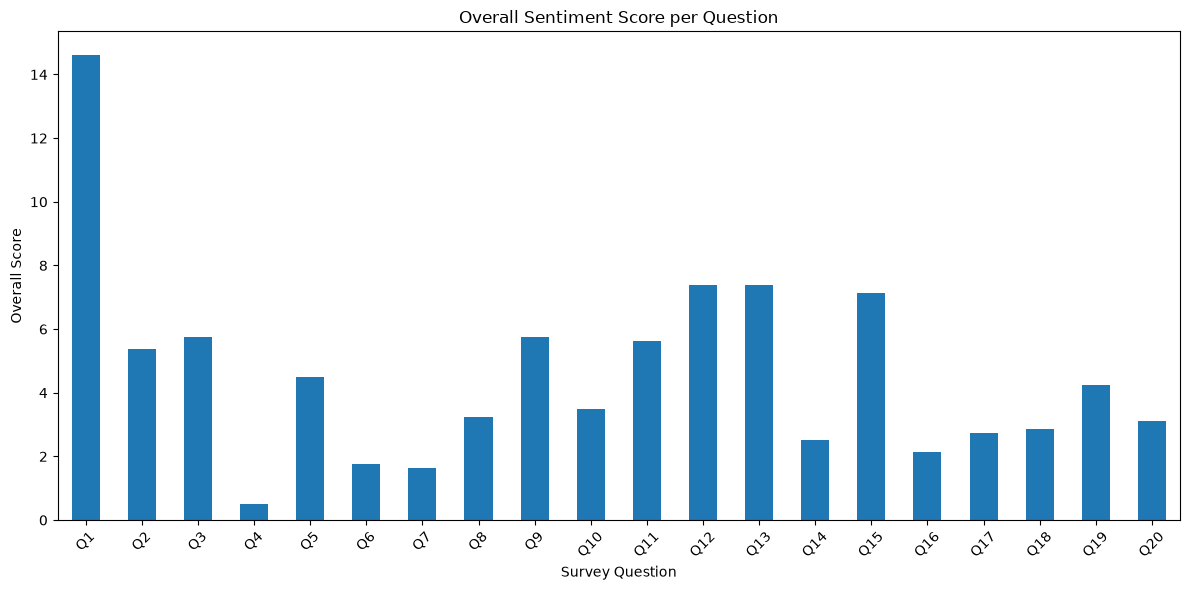

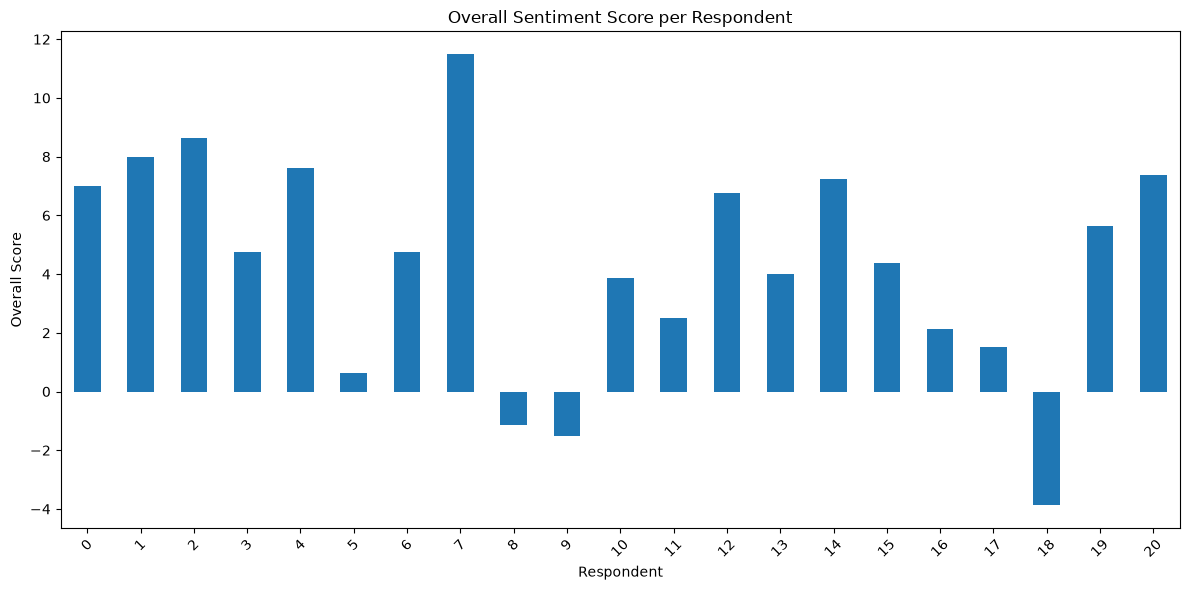

<Figure size 1200x600 with 0 Axes>

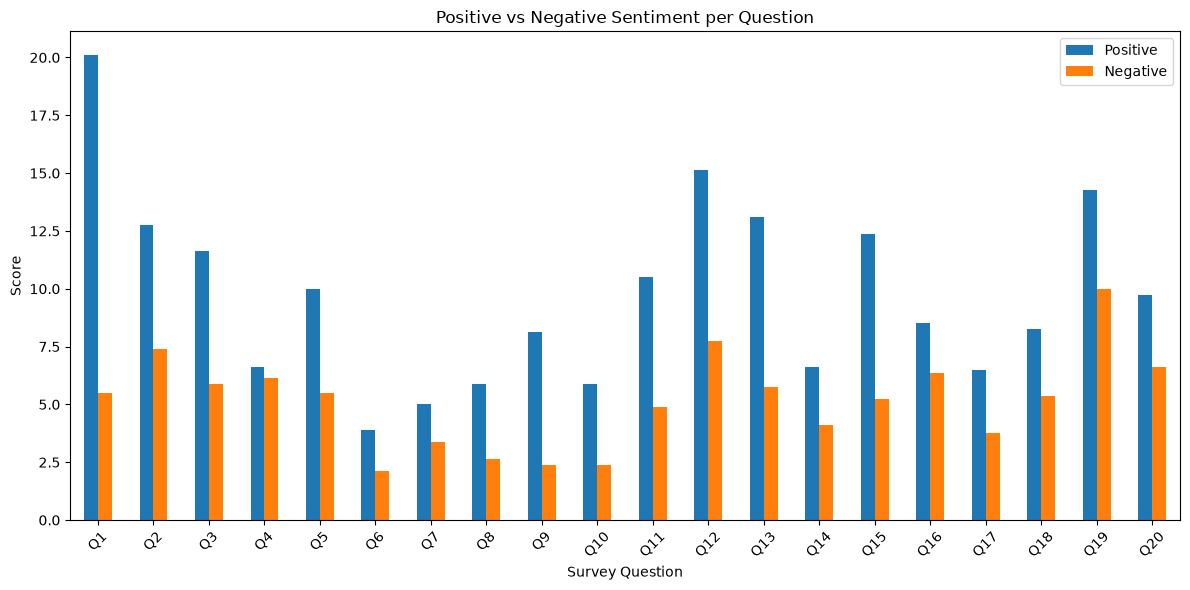

In [6]:
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12, 6))
question_score_plot.plot(kind="bar")
plt.title("Overall Sentiment Score per Question")
plt.xlabel("Survey Question")
plt.ylabel("Overall Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/overall_sentiment_per_question.png")
plt.show()

# overall sentiment score per respondent
plt.figure(figsize=(12, 6))
overall_person_score.plot(kind="bar")
plt.title("Overall Sentiment Score per Respondent")
plt.xlabel("Respondent")
plt.ylabel("Overall Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/overall_sentiment_per_respondent.png")
plt.show()

# pos vs neg sentiment score per question
plt.figure(figsize=(12, 6))
comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Positive vs Negative Sentiment per Question")
plt.xlabel("Survey Question")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/positive_vs_negative_per_question.png")
plt.show()

In [9]:
def analyze_text(text):
    print("\nInput text:", text)
    
    text_lower = text.lower()
    print("\nLowercase:", text_lower)

    tokens = word_tokenize(text_lower)
    print("\nTokens:", tokens)
    
    bigram_list = list(bigrams(tokens))
    print("\nBigrams:", bigram_list)

    positive, negative = sentiment_score(text)
    overall = positive - negative
    
    print("\nFinal Scores:")
    print(f" Positive Score: {positive:.2f}")
    print(f" Negative Score: {negative:.2f}")
    print(f" Overall Score: {overall:.2f}" )

    if overall > 0:
        sentiment = "Positive"
    elif overall < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    print("Final Sentiment:", sentiment)
    return sentiment
    
user_text = input("Enter a sentence to analyze: ")
analyze_text(user_text)

Enter a sentence to analyze:  I hope there are no errors in this program.



Input text: I hope there are no errors in this program.

Lowercase: i hope there are no errors in this program.

Tokens: ['i', 'hope', 'there', 'are', 'no', 'errors', 'in', 'this', 'program', '.']

Bigrams: [('i', 'hope'), ('hope', 'there'), ('there', 'are'), ('are', 'no'), ('no', 'errors'), ('errors', 'in'), ('in', 'this'), ('this', 'program'), ('program', '.')]

Final Scores:
 Positive Score: 0.88
 Negative Score: 0.12
 Overall Score: 0.75
Final Sentiment: Positive


'Positive'